In [2]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Nikhil Bidkar\retail-analytics\bigquery_key.json"

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project="retail-analytics-493018")
print("Connected!")


Connected!


In [3]:
# RFM Analysis
rfm_query = """
WITH last_order_date AS (
    SELECT MAX(DATE(order_purchase_timestamp)) AS max_date
    FROM `retail-analytics-493018.olist_raw.orders`
),

rfm AS (
    SELECT
        o.customer_id,
        DATE_DIFF(l.max_date, MAX(DATE(o.order_purchase_timestamp)), DAY) AS recency,
        COUNT(o.order_id) AS frequency,
        ROUND(SUM(p.payment_value), 2) AS monetary
    FROM `retail-analytics-493018.olist_raw.orders` o
    JOIN `retail-analytics-493018.olist_raw.payments` p ON o.order_id = p.order_id
    CROSS JOIN last_order_date l
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id, l.max_date
)

SELECT * FROM rfm
ORDER BY monetary DESC
"""

rfm = client.query(rfm_query).to_dataframe()
print(rfm.shape)
print(rfm.head())

C:\Users\Nikhil Bidkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(96477, 4)
                        customer_id  recency  frequency  monetary
0  1617b1357756262bfa56ab541c47bc16      383          1  13664.08
1  ec5b2ba62e574342386871631fafd3fc       94          1   7274.88
2  c6e2731c5b391845f6800c97401a43a9      612          1   6929.31
3  f48d464a0baaea338cb25f816991ab1f       84          1   6922.21
4  3fd6777bbce08a352fddd04e4a7cc8f6      511          1   6726.66


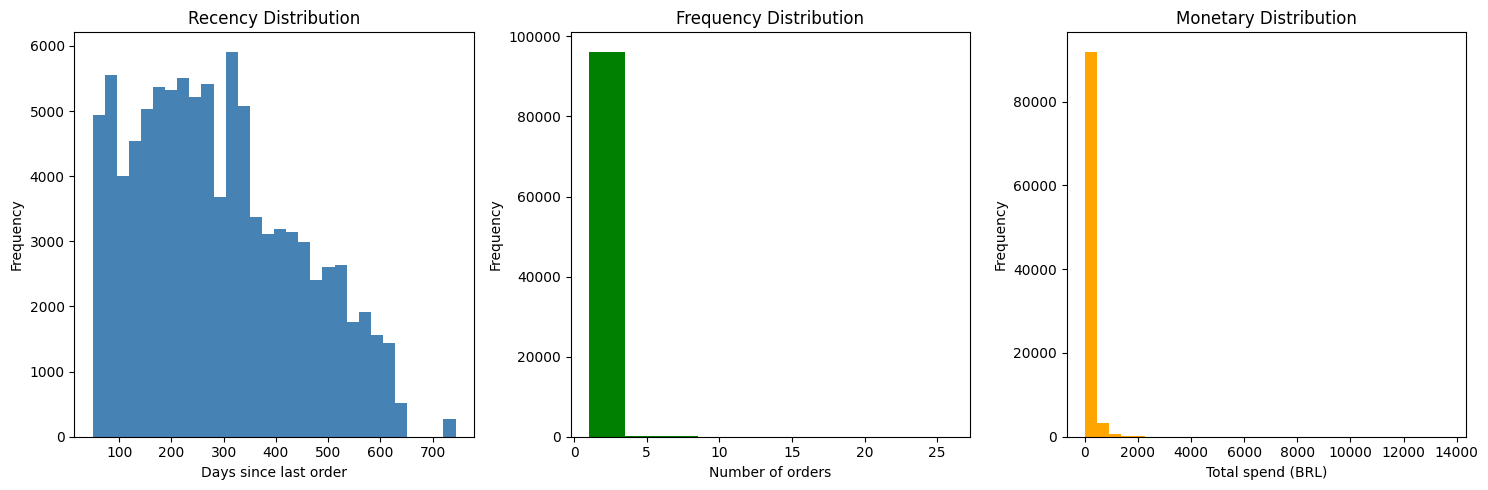

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfm['recency'].plot(kind='hist', bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last order')

rfm['frequency'].plot(kind='hist', bins=10, ax=axes[1], color='green')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

rfm['monetary'].plot(kind='hist', bins=30, ax=axes[2], color='orange')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (BRL)')

plt.tight_layout()
plt.show()

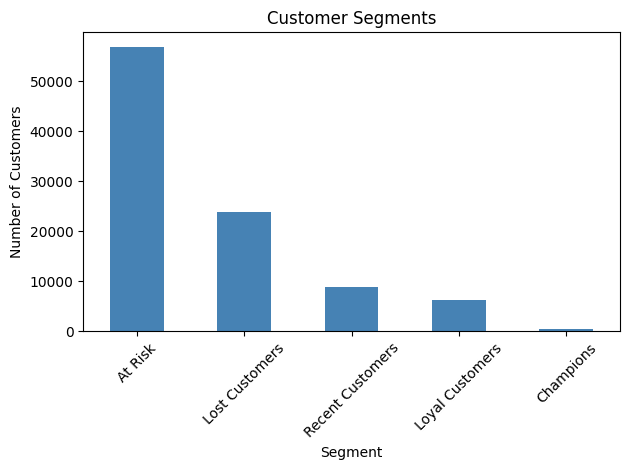

segment
At Risk             56960
Lost Customers      23897
Recent Customers     8906
Loyal Customers      6231
Champions             483
Name: count, dtype: int64


In [5]:
# Segment customers based on RFM scores
def segment_customer(row):
    if row['recency'] <= 100 and row['monetary'] >= 500:
        return 'Champions'
    elif row['recency'] <= 200 and row['monetary'] >= 200:
        return 'Loyal Customers'
    elif row['recency'] <= 100:
        return 'Recent Customers'
    elif row['recency'] >= 400:
        return 'Lost Customers'
    else:
        return 'At Risk'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Plot segments
rfm['segment'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(rfm['segment'].value_counts())